# Week 3: Evaluation using reference ground-truth, mitigation, and calibration

You now receive:

- `week3_validation_reference.csv`
- `week3_test_observed.csv`
- `week3_test_reference.csv`

These files let you compare evaluation against the labels available to the modelling pipeline, $Y^{obs}$, and the best available reference labels, $Y^{ref}$.

You now receive the "clean" reference labels (`income_reference`) for the validation and test sets. 

Your objective this week is to uncover the **root cause** of the biases and anomalies you hypothesized in Week 2. By comparing your model's performance against the observed labels ($Y^{obs}$) versus the clean reference labels ($Y^{ref}$), you will finally validate (or invalidate!) your previous hypotheses.

Once you have identified the true source of the bias, you will design and implement a mitigation strategy of your choice to correct it. 

**Rules**
- Do not train a predictive model on `income_reference`.                                    
- Reference validation may be used for final model selection or calibration only if you explicitly state and defend that design choice.                         
- Reference test is used exactly *once* for your final evaluation.                                         
- Preserve `row_id` when joining files and verify one-to-one joins.

In [ ]:
%pip -q install fairlearn cleanlab scikit-learn pandas matplotlib seaborn

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
DATA_DIR = Path("data")

train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
val_obs = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
val_ref = pd.read_csv(DATA_DIR / "week3_validation_reference.csv")
test_obs = pd.read_csv(DATA_DIR / "week3_test_observed.csv")
test_ref = pd.read_csv(DATA_DIR / "week3_test_reference.csv")

# TODO: assert unique row_id values and exact alignment of feature columns.
assert train['row_id'].is_unique, "Train row_id values are not unique"
assert val_obs['row_id'].is_unique, "Validation observed row_id values are not unique"
assert val_ref['row_id'].is_unique, "Validation reference row_id values are not unique"
print(train.shape, val_obs.shape, val_ref.shape, test_obs.shape, test_ref.shape)

(18000, 15) (6000, 15) (6000, 16) (6000, 15) (6000, 16)


To start with - Compare $Y^{obs}$ and $Y^{ref}$ on validation and test data. Report overall disagreement, disagreement conditional on each label, group-specific disagreement, and intersections. Inspect which feature regions contain disagreements without assuming the reference label is infallible.

In [3]:
(test_ref['income_observed'] != test_obs['income_observed']).sum(), (val_ref['income_observed'] != val_obs['income_observed']).sum()

(np.int64(0), np.int64(0))

Dataset: validation_reference
  Total rows: 6000
  Total disagreements: 242.0 (4.03%)
  Disagreements by label:
    n_disagree_income_1: 30.0
    pct_disagree_income_1: 0.014955134596211365
    n_disagree_income_0: 212.0
    pct_disagree_income_0: 0.053079619429143715

Dataset: test_reference
  Total rows: 6000
  Total disagreements: 249.0 (4.15%)
  Disagreements by label:
    n_disagree_income_0: 223.0
    pct_disagree_income_0: 0.05563872255489022
    n_disagree_income_1: 26.0
    pct_disagree_income_1: 0.013052208835341365

Disagreement matrix for validation_reference:


,AIAN specified/other,American Indian,Asian,Black,Other race,Pacific Islander,Two or more races,White
Female,0.0,1.0,27.0,12.0,3.0,0.0,2.0,159.0
Male,0.0,0.0,3.0,0.0,0.0,0.0,4.0,31.0


Disagreement matrix for test_reference:


,AIAN specified/other,American Indian,Asian,Black,Other race,Pacific Islander,Two or more races,White
Female,0.0,1.0,10.0,26.0,4.0,0.0,4.0,147.0
Male,0.0,0.0,2.0,3.0,5.0,0.0,0.0,47.0


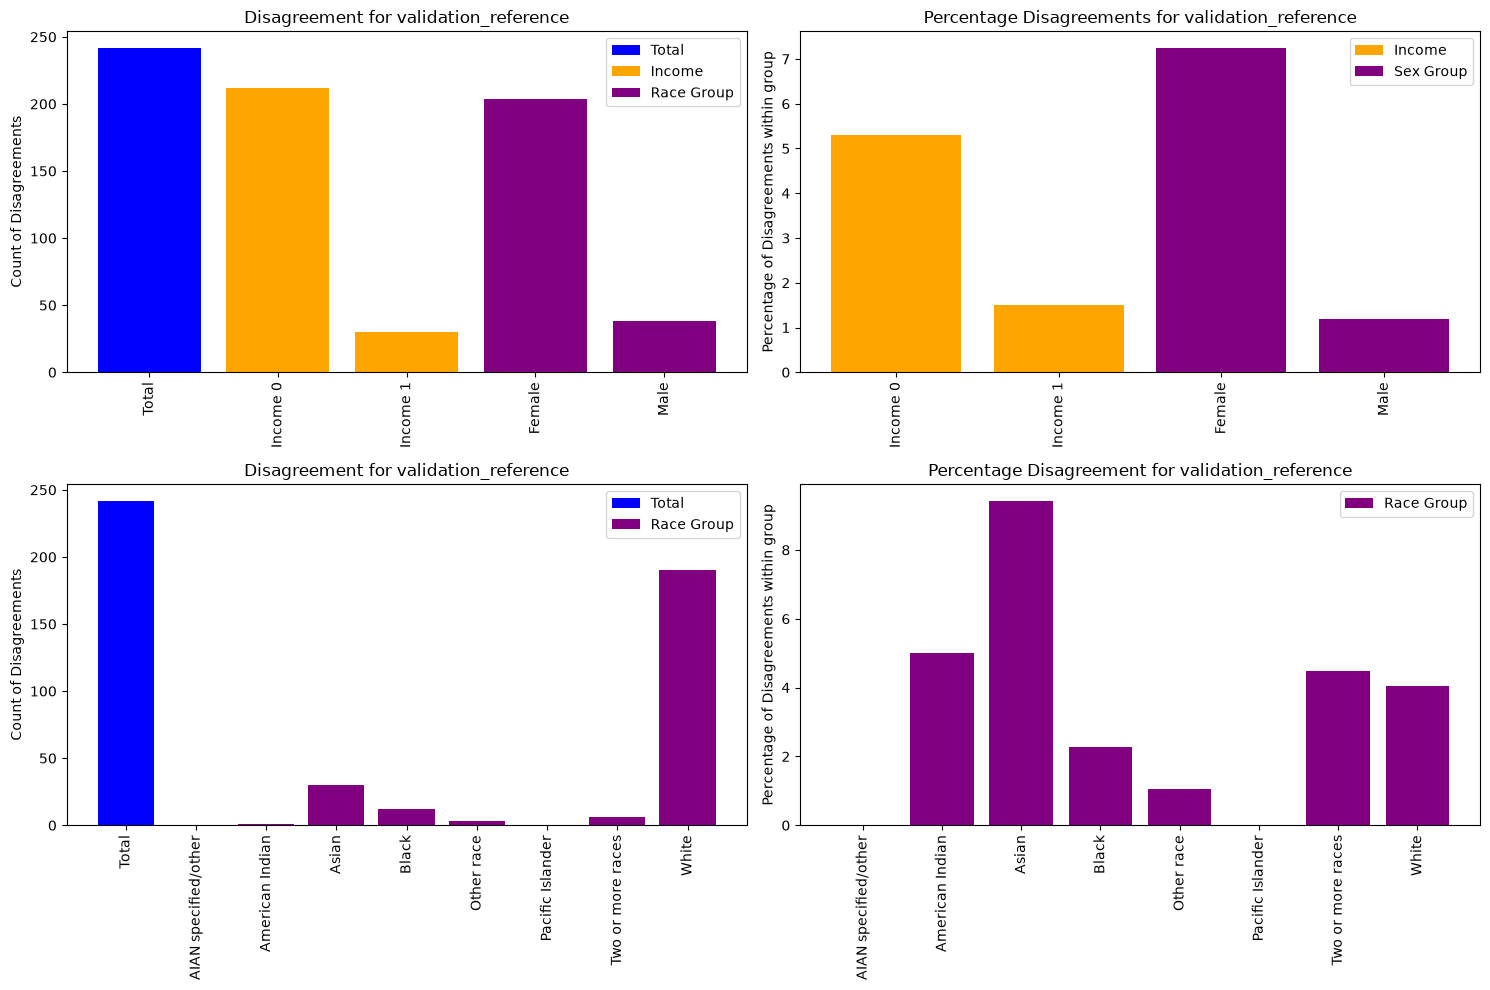

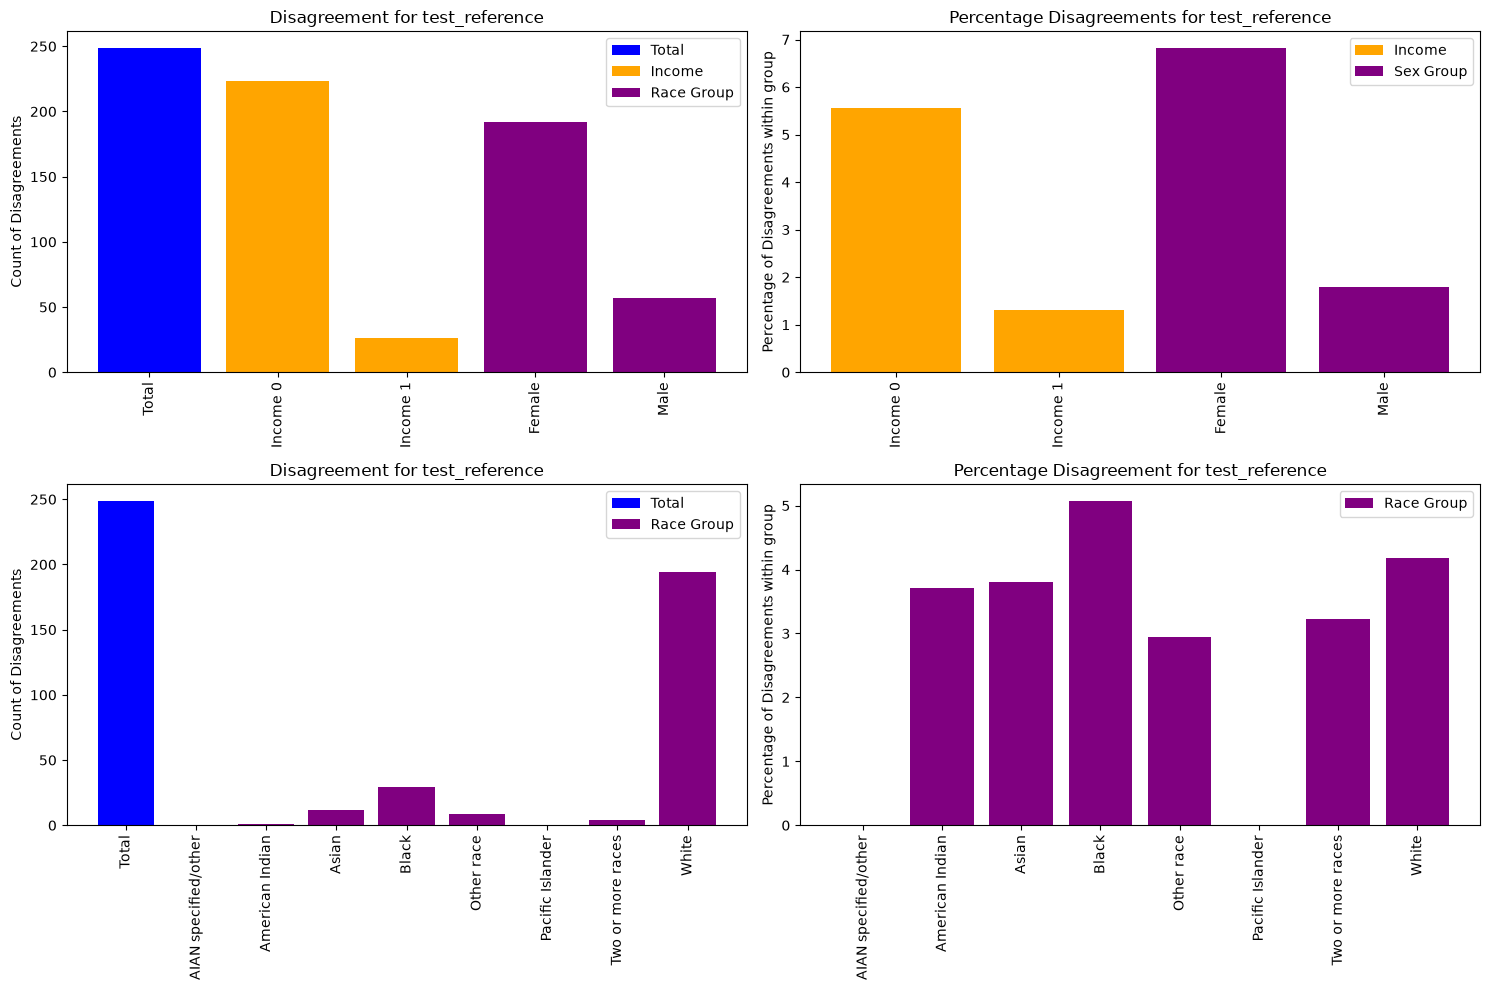

In [4]:
# TODO: join observed and reference files by row_id.
DATAFRAMES = {"train":train, "validation_observed": val_obs, "validation_reference": val_ref, "test_observed": test_obs, "test_reference": test_ref}
SENSITIVE_ATTRIBUTES = ["SEX_group", "RACE_group"]
# TODO: quantify and visualize label disagreement.
# Overall Disagreement
def summarize_disagreement(ref_dfs, observed_col="income_observed", reference_col="income_reference"):
    summary = {}
    for name, df in ref_dfs.items():
        summary_item = {}
        assert reference_col in df.columns, f"{name} does not have a {reference_col} column"
        assert observed_col in df.columns, f"{name} does not have a {observed_col} column"
        summary_item["n_rows"] = len(df)
        
        # Disagreement counts and percentages
        n_disagree = (df[observed_col] != df[reference_col]).sum()
        summary_item["n_disagree"] = float(n_disagree)
        summary_item["pct_disagree"] = float(n_disagree / len(df))
        
        # Disagreement by label value
        label_disagreement = {}
        for label in df[observed_col].unique():
            n_disagree_label = ((df[observed_col] == label) & (df[observed_col] != df[reference_col])).sum()
            label_disagreement[f"n_disagree_income_{label}"] = float(n_disagree_label)
            label_disagreement[f"pct_disagree_income_{label}"] = float(n_disagree_label / (df[observed_col] == label).sum())
        summary_item["label_disagreement"] = label_disagreement
        
        # Disagreement by sensitive attribute value
        sens_dict = {}
        for attr in SENSITIVE_ATTRIBUTES:
            for value in df[attr].unique():
                n_disagree_attr = ((df[attr] == value) & (df[observed_col] != df[reference_col])).sum()
                sens_dict[f"n_disagree_{attr}_{value}"] = float(n_disagree_attr)
                sens_dict[f"pct_disagree_{attr}_{value}"] = float(n_disagree_attr / (df[attr] == value).sum())
        summary_item["sensitive_disagreement"] = sens_dict
        
        # Disagreement by intersection of sensitive attribute values
        intersection_dict = {}
        for attr1 in SENSITIVE_ATTRIBUTES:
            for value1 in df[attr1].unique():
                for attr2 in SENSITIVE_ATTRIBUTES:
                    if attr1 == attr2:
                        continue
                    for value2 in df[attr2].unique():
                        n_disagree_intersection = ((df[attr1] == value1) & (df[attr2] == value2) & (df[observed_col] != df[reference_col])).sum()
                        intersection_dict[f"n_disagree_{attr1}_{value1}_{attr2}_{value2}"] = float(n_disagree_intersection)
                        intersection_dict[f"pct_disagree_{attr1}_{value1}_{attr2}_{value2}"] = float(n_disagree_intersection / ((df[attr1] == value1) & (df[attr2] == value2)).sum())
        summary_item["intersection_disagreement"] = intersection_dict
        
        summary[name] = summary_item
    return summary

def sex_race_disagreement_matrix(name, summary_item):
    matrix = pd.DataFrame(index=sorted(DATAFRAMES[name]['SEX_group'].unique()), columns=sorted(DATAFRAMES[name]['RACE_group'].unique()))
    
    for sex in matrix.index:
        for race in matrix.columns:
            n_disagree = summary_item['intersection_disagreement'].get(f"n_disagree_SEX_group_{sex}_RACE_group_{race}", 0)
            matrix.loc[sex, race] = n_disagree
    return matrix


def print_disagreement_summary(summary, label_grouping=True, sensitive_grouping=True, intersection_grouping=True):
    for name, summary_item in summary.items():
        print(f"Dataset: {name}")
        print(f"  Total rows: {summary_item['n_rows']}")
        print(f"  Total disagreements: {summary_item['n_disagree']} ({summary_item['pct_disagree']*100:.2f}%)")
        
        if label_grouping:
            print("  Disagreements by label:")
            for label, value in summary_item["label_disagreement"].items():
                print(f"    {label}: {value}")
                
        if sensitive_grouping:
            print("  Disagreements by sensitive attribute:")
            for attr, value in summary_item["sensitive_disagreement"].items():
                print(f"    {attr}: {value}")
                
        if intersection_grouping:
            print("  Disagreements by intersection of sensitive attributes:")
            for intersection, value in summary_item["intersection_disagreement"].items():
                print(f"    {intersection}: {value}")
        print()
        
def plot_disagreement_summary(summary):
    for name, summary_item in summary.items():
        n_rows = 2
        fig, axes = plt.subplots(n_rows, 2, figsize=(15, 5 * n_rows))
        axes = axes.flatten()
        
        
        axes[0].bar(["Total"], [summary_item['n_disagree']], color='blue', label="Total")
        # Disagreements by label
        axes[0].bar(["Income 0", "Income 1"], [summary_item['label_disagreement']['n_disagree_income_0'], summary_item['label_disagreement']['n_disagree_income_1']], color='orange', label="Income")
        # Disagreements by sex groups
        sex_groups = sorted(DATAFRAMES[name]['SEX_group'].unique())
        axes[0].bar(sex_groups, [summary_item['sensitive_disagreement'][f'n_disagree_SEX_group_{race}'] for race in sex_groups], color='purple', label="Race Group")
        axes[0].set_ylabel("Count of Disagreements")
        axes[0].set_title(f"Disagreement for {name}")
        axes[0].legend() 
        axes[0].tick_params(axis='x', rotation=90)       
        
        # Percentage of disagreements by label
        axes[1].bar(["Income 0", "Income 1"], [summary_item['label_disagreement']['pct_disagree_income_0']*100, summary_item['label_disagreement']['pct_disagree_income_1']*100], color='orange', label="Income")
        # Percentage of disagreements by sex groups
        axes[1].bar(sex_groups, [summary_item['sensitive_disagreement'][f'pct_disagree_SEX_group_{race}']*100 for race in sex_groups], color='purple', label="Sex Group")
        axes[1].set_ylabel("Percentage of Disagreements within group")
        axes[1].set_title(f"Percentage Disagreements for {name}")
        axes[1].legend()
        axes[1].tick_params(axis='x', rotation=90)
                
        # Disagreements by Race groups
        race_groups = sorted(DATAFRAMES[name]['RACE_group'].unique())
        axes[2].bar(["Total"], [summary_item['n_disagree']], color='blue', label="Total")
        axes[2].bar(race_groups, [summary_item['sensitive_disagreement'][f'n_disagree_RACE_group_{race}'] for race in race_groups], color='purple', label="Race Group")
        axes[2].set_ylabel("Count of Disagreements")
        axes[2].set_title(f"Disagreement for {name}")
        axes[2].legend()
        axes[2].tick_params(axis='x', rotation=90)
        
        # Percentage of disagreements by Race groups
        axes[3].bar(race_groups, [summary_item['sensitive_disagreement'][f'pct_disagree_RACE_group_{race}']*100 for race in race_groups], color='purple', label="Race Group")
        axes[3].set_ylabel("Percentage of Disagreements within group")
        axes[3].set_title(f"Percentage Disagreement for {name}")
        axes[3].legend()
        axes[3].tick_params(axis='x', rotation=90)
        
        plt.tight_layout()
        plt.show()

summary = summarize_disagreement({key: value for key, value in DATAFRAMES.items() if "reference" in key})
print_disagreement_summary(summary, label_grouping=True, sensitive_grouping=False, intersection_grouping=False)
for name, summary_item in summary.items():
    print(f"Disagreement matrix for {name}:")
    matrix = sex_race_disagreement_matrix(name, summary_item)
    display(matrix)
plot_disagreement_summary(summary)


# TODO: test the Week 2 hypotheses without reading the new metadata.


Re-evaluate the original model twice

For the same scores and decisions, produce two complete audits:

1. against `income_observed`;
2. against `income_reference`.

Any difference is caused by the evaluation target, not by a changed model. Discuss which conclusions reverse or materially change.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# TODO: reconstruct your Week 2 baseline.
LABEL = "income_observed"
ID = "row_id"
SENSITIVE1 = "SEX_group"
SENSITIVE2 = "RACE_group"

#FEATURE_COLUMNS = ["AGEP", "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "WKHP"]
NUMERIC_FEATURES = ["AGEP", "SCHL", "WKHP"]
CATEGORICAL_FEATURES = ["COW", "MAR", "OCCP", "POBP", "RELP"]
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

def make_model(frame):
    numeric = [c for c in NUMERIC_FEATURES if c in frame.columns]
    categorical = [c for c in CATEGORICAL_FEATURES if c in frame.columns]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000)),
    ])

lr_model = make_model(train)
lr_model.fit(train[FEATURE_COLUMNS], train[LABEL])

lr_train_pred = lr_model.predict(DATAFRAMES['train'][FEATURE_COLUMNS])
lr_train_proba = lr_model.predict_proba(DATAFRAMES['train'][FEATURE_COLUMNS])[:,1]

lr_val_pred = lr_model.predict(DATAFRAMES['validation_observed'][FEATURE_COLUMNS])
lr_val_proba = lr_model.predict_proba(DATAFRAMES['validation_observed'][FEATURE_COLUMNS])[:,1]

lr_test_pred = lr_model.predict(DATAFRAMES['test_observed'][FEATURE_COLUMNS])
lr_test_proba = lr_model.predict_proba(DATAFRAMES['test_observed'][FEATURE_COLUMNS])[:,1]

def baseline_model(X):
    # Simple baseline model: predict income based on education level (SCHL)
    return (X['SCHL'] >= 21).astype(int)  # 21 corresponds to Bachelor's Degree

baseline_train_pred = baseline_model(DATAFRAMES['train'])
baseline_val_pred = baseline_model(DATAFRAMES['validation_observed'])
baseline_test_pred = baseline_model(DATAFRAMES['test_observed'])

In [40]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, precision_score, recall_score, brier_score_loss, log_loss
from fairlearn.metrics import MetricFrame, selection_rate, count, equalized_odds_difference, equalized_odds_ratio, demographic_parity_difference, demographic_parity_ratio


# TODO: create a reusable audit function accepting y_eval, scores, predictions, and sensitive features.
def true_positive_rate(y_true, y_pred):
    return recall_score(y_true, y_pred, pos_label=1, zero_division=0)

def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    denominator = tn + fp
    return fp / denominator if denominator > 0 else np.nan

def positive_predictive_value(y_true, y_pred):
    return precision_score(y_true, y_pred, pos_label=1, zero_division=0)

def negative_predictive_value(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    denominator = tn + fn
    return tn / denominator  if denominator else np.nan

def ppv_difference(y_true, y_pred, sensitive_features):
    mf = MetricFrame(metrics=positive_predictive_value, y_true=y_true, y_pred=y_pred, sensitive_features=sensitive_features)
    return mf.difference(method='between_groups')

def npv_difference(y_true, y_pred, sensitive_features):
    mf = MetricFrame(metrics=negative_predictive_value, y_true=y_true, y_pred=y_pred, sensitive_features=sensitive_features)
    return mf.difference(method='between_groups')

def expected_calibration_error(y_true, y_proba, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_proba, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        mask = binids == i
        if np.sum(mask) > 0:
            prop_in_bin = np.mean(mask)
            acc_in_bin = np.mean(y_true[mask])
            conf_in_bin = np.mean(y_proba[mask])
            ece += np.abs(conf_in_bin - acc_in_bin) * prop_in_bin
    return ece

LABEL_METRICS = {
    "count": count,
    "selection_rate": selection_rate,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "tpr": true_positive_rate,
    "fpr": false_positive_rate,
    "ppv": positive_predictive_value,
    "npv": negative_predictive_value,
}

proba_metrics = {
    "brier_score": brier_score_loss,
    "ece": expected_calibration_error
}
    

def audit_model(y_eval, scores, predictions, sensitive_features):
    """
        y_eval: true labels
        scores: predicted probabilities
        predictions: predicted labels
        sensitive_features: DataFrame containing sensitive attributes
    """
    audit = {}
    
    # Calculate accuracy and balanced accuracy
    label_mf = MetricFrame(
        metrics=LABEL_METRICS,
        y_true=y_eval,
        y_pred=predictions,
        sensitive_features=sensitive_features,
    )
    proba_mf = MetricFrame(
        metrics=proba_metrics,
        y_true=y_eval,
        y_pred=scores,
        sensitive_features=sensitive_features
    )
    
    overall_report = pd.concat([label_mf.overall, proba_mf.overall])
    audit['overall'] = overall_report
    
    group_report = pd.concat([label_mf.by_group, proba_mf.by_group], axis=1)
    audit['by_group'] = group_report
    
    
    disparity_summary = pd.Series({
        # --- INDEPENDENCE ---
        "independence_demographic_parity_diff": demographic_parity_difference(
            y_true=y_eval, y_pred=predictions, sensitive_features=sensitive_features
        ),
        "independence_demographic_parity_ratio": demographic_parity_ratio(
            y_true=y_eval, y_pred=predictions, sensitive_features=sensitive_features
        ),
        
        # --- SEPARATION ---
        "separation_equalized_odds_diff": equalized_odds_difference(
            y_true=y_eval, y_pred=predictions, sensitive_features=sensitive_features
        ),
        "separation_equalized_odds_ratio": equalized_odds_ratio(
            y_true=y_eval, y_pred=predictions, sensitive_features=sensitive_features
        ),
        
        # --- SUFFICIENCY ---
        "sufficiency_ppv_difference": ppv_difference(
            y_true=y_eval, y_pred=predictions, sensitive_features=sensitive_features
        ),
        "sufficiency_npv_difference": npv_difference(
            y_true=y_eval, y_pred=predictions, sensitive_features=sensitive_features
        ),
    })
    audit['disparity'] = disparity_summary
    
    
    return audit

def display_audit_results(audit, name=None):
    print("="*80)
    if name:
        print(f"Audit results for {name}:")
    print("=== Overall threshold metrics ===")
    display(audit['overall'])
    print("\n=== Group-Level Metrics ===")
    display(audit['by_group'])
    print("\n=== Fairness & Disparity Summary ===")
    display(audit['disparity'])

In [82]:
# TODO: report utility, independence, separation, sufficiency, and calibration twice.
def evaluate_model(df, lr_model, label):
    scores = lr_model.predict_proba(df[FEATURE_COLUMNS])[:, 1]
    predictions = lr_model.predict(df[FEATURE_COLUMNS])
    
    return scores, predictions

y_eval_obs, y_eval_ref = DATAFRAMES['validation_reference'][['income_observed', 'income_reference']].values.T
scores, predictions = evaluate_model(DATAFRAMES['validation_reference'], lr_model, 'income_observed')
scores, predictions = evaluate_model(DATAFRAMES['validation_reference'], lr_model, 'income_reference')

sens_attr = [SENSITIVE1]
audit_obs = audit_model(y_eval_obs, scores, predictions, DATAFRAMES['validation_reference'][sens_attr])
audit_ref = audit_model(y_eval_ref, scores, predictions, DATAFRAMES['validation_reference'][sens_attr])
display_audit_results(audit_obs, name = f"audit=validation_observed_{'_'.join(sens_attr)}")
display_audit_results(audit_ref, name = f"audit=validation_reference_{'_'.join(sens_attr)}")

Audit results for audit=validation_observed_SEX_group:
=== Overall threshold metrics ===


count                6000.000000
selection_rate          0.296167
accuracy                0.786167
balanced_accuracy       0.745591
tpr                     0.623131
fpr                     0.131948
ppv                     0.703433
npv                     0.820980
brier_score             0.146290
ece                     0.010184
dtype: float64


=== Group-Level Metrics ===


,count,selection_rate,accuracy,balanced_accuracy,tpr,fpr,ppv,npv,brier_score,ece
SEX_group,,,,,,,,,,
Female,2812.0,0.216572,0.790541,0.692428,0.516026,0.13117,0.528736,0.862914,0.139591,0.056987
Male,3188.0,0.366374,0.782309,0.769300,0.671491,0.13289,0.794521,0.775248,0.152199,0.050475



=== Fairness & Disparity Summary ===


...

count                6000.000000
selection_rate          0.296167
accuracy                0.797500
balanced_accuracy       0.761486
tpr                     0.628428
fpr                     0.105456
ppv                     0.773776
npv                     0.807483
brier_score             0.140852
ece                     0.032449
dtype: float64


=== Group-Level Metrics ===


,count,selection_rate,accuracy,balanced_accuracy,tpr,fpr,ppv,npv,brier_score,ece
SEX_group,,,,,,,,,,
Female,2812.0,0.216572,0.814011,0.735205,0.554156,0.083746,0.722496,0.839310,0.129744,0.032396
Male,3188.0,0.366374,0.782936,0.770427,0.670732,0.129877,0.800514,0.772772,0.150650,0.054239



=== Fairness & Disparity Summary ===


independence_demographic_parity_diff     0.149802
independence_demographic_parity_ratio    0.591122
separation_equalized_odds_diff           0.116576
separation_equalized_odds_ratio          0.644810
sufficiency_ppv_difference               0.078018
sufficiency_npv_difference               0.066538
dtype: float64

HintL Design mitigation candidates

Compare at least four methods you could think of. You may add models. Every intervention requires a  rationale and a documented cost/tradeoff.

**1. Removing sensitive attributes**: The model will like just find proxy variables that correlate with the missing sensitive features. This means that it often does not make the model more fair.

**2. Correlation removal**: Transform input features so they are statistically independent from the sensitive features (Like linear project). Degrades meaning of features and could negative impact model performance. This also specifically targets Independence, but not Seperation and Sufficiency.

**3. Training constraint**: Add fairness to the loss function, so that it optimizes for both model accuracy and model fairness. You would have to pick one fairness metric or pick multiple and then weigh them in importance when making the new loss function. This would infer a tradeoff between model accuracy and model fairness. It could also make the model training much slower.

**4. Threshold Optimization**: Used in Week 2. Adjusts decision threshold during inference for each specific group in the sensitive feature. This enforces Seperation (Equalized-odds). Can make it so that predictions that the model actually predicted correctly are flipped to an incorrect prediction when thresholding.

In [80]:
# Got from Gemini
from fairlearn.preprocessing import CorrelationRemover
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

class CorrelationRemoverModel:
    """Wrapper that applies ColumnTransformer, appends sensitive features, 

    runs CorrelationRemover, and predicts with Logistic Regression.
    """
    def __init__(self, preprocessor, sensitive_col_name, random_seed=42):
        self.preprocessor = preprocessor
        self.sensitive_col_name = sensitive_col_name
        self.cr = CorrelationRemover(sensitive_feature_ids=[sensitive_col_name])
        self.clf = LogisticRegression(random_state=random_seed, max_iter=1000)

    def _prepare_data(self, X, A):
        # 1. Transform features via ColumnTransformer
        X_proc = self.preprocessor.transform(X)
        
        # 2. Convert to DataFrame with feature names
        feat_cols = [f"feat_{i}" for i in range(X_proc.shape[1])]
        X_df = pd.DataFrame(X_proc, columns=feat_cols, index=X.index)
        
        # 3. Add sensitive attribute as numeric (0/1)
        A_numeric = (A == A.unique()[0]).astype(float)
        X_df[self.sensitive_col_name] = A_numeric
        return X_df

    def fit(self, X, y, A):
        # Fit preprocessor on X
        self.preprocessor.fit(X)
        X_df = self._prepare_data(X, A)
        
        # Fit CorrelationRemover and Logistic Regression
        X_cr = self.cr.fit_transform(X_df)
        self.clf.fit(X_cr, y)
        return self

    def predict(self, X, A):
        X_df = self._prepare_data(X, A)
        X_cr = self.cr.transform(X_df)
        return self.clf.predict(X_cr)

    def predict_proba(self, X, A):
        X_df = self._prepare_data(X, A)
        X_cr = self.cr.transform(X_df)
        return self.clf.predict_proba(X_cr)

class InProcessingEGModel:
    """
    Wrapper for ExponentiatedGradient that preprocesses features first,
    allowing LogisticRegression to receive sample_weight directly.
    """
    def __init__(self, preprocessor, random_seed=42):
        self.preprocessor = preprocessor
        self.random_seed = random_seed
        self.base_clf = LogisticRegression(random_state=random_seed, max_iter=1000)
        self.eg_model = ExponentiatedGradient(
            estimator=self.base_clf,
            constraints=EqualizedOdds(),
            max_iter=50
        )

    def fit(self, X, y, A):
        np.random.seed(self.random_seed)
        # 1. Transform features via ColumnTransformer
        X_proc = self.preprocessor.fit_transform(X)
        # 2. Fit ExponentiatedGradient directly on preprocessed features
        self.eg_model.fit(X_proc, y, sensitive_features=A)
        return self

    def predict(self, X):
        X_proc = self.preprocessor.transform(X)
        return self.eg_model.predict(X_proc)

    def predict_proba(self, X):
        X_proc = self.preprocessor.transform(X)
        # ExponentiatedGradient uses _pmf_predict to yield probability distributions over classes
        probs = self.eg_model._pmf_predict(X_proc)
        return np.clip(probs, 0.0, 1.0)

In [81]:
# TODO: define the candidates and a common experiment protocol.
# Keep preprocessing, split, random seed, and evaluation consistent.
from fairlearn.postprocessing import ThresholdOptimizer

RANDOM_SEED = 42
LABEL = "income_observed"
SENSITIVE = "SEX_group"

NUMERIC_FEATURES = ["AGEP", "SCHL", "WKHP"]
CATEGORICAL_FEATURES = ["COW", "MAR", "OCCP", "POBP", "RELP"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Standard Preprocessor
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
])

# Extracted training/validation sets to ensure identical splits
X_train = DATAFRAMES['train'][ALL_FEATURES]
y_train = DATAFRAMES['train'][LABEL]
A_train = DATAFRAMES['train'][SENSITIVE]

X_val = DATAFRAMES['validation_observed'][ALL_FEATURES]
y_val = DATAFRAMES['validation_observed'][LABEL]
A_val = DATAFRAMES['validation_observed'][SENSITIVE]

def train_unawareness_baseline():
    """Method 1: Baseline model completely blind to the sensitive attribute."""
    print("Training Unawareness Baseline Model...")
    model = Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(random_state=RANDOM_SEED, max_iter=1000))
    ])
    model.fit(X_train, y_train)
    return model

def train_correlation_remover(): # Got from Gemini
    """Method 2: Pre-processing to strip sensitive correlations from features."""
    print("Training Correlation Remover Model...")
    model = CorrelationRemoverModel(
        preprocessor=preprocessor, 
        sensitive_col_name=SENSITIVE, 
        random_seed=RANDOM_SEED
    )
    model.fit(X_train, y_train, A_train)
    return model

def train_inprocessing_eg(): # Got from Gemini
    """Method 3: In-processing optimizing for Equalized Odds."""
    print("Training In-Processing Exponentiated Gradient Model...")
    model = InProcessingEGModel(preprocessor=preprocessor, random_seed=RANDOM_SEED)
    model.fit(X_train, y_train, A_train)
    return model

def train_postprocessing_threshold():
    """Method 4: Post-processing to equalize TPR/FPR via group thresholds."""
    print("Training Post-Processing Threshold Optimizer Model...")
    base_clf = train_unawareness_baseline()
    
    # ThresholdOptimizer adjusts decision boundaries on top of a pre-fit model
    post_model = ThresholdOptimizer(
        estimator=base_clf,
        constraints="equalized_odds",
        predict_method="predict_proba",
        prefit=True # Uses the already trained baseline
    )
    
    # Post-processor requires validation data to tune thresholds properly without overfitting
    post_model.fit(X_val, y_val, sensitive_features=A_val)
    return post_model

candidates = {
    "1_Unawareness": train_unawareness_baseline(),
    "2_PreProcessing_CR": train_correlation_remover(),
    "3_InProcessing_EG": train_inprocessing_eg(),
    "4_PostProcessing_TO": train_postprocessing_threshold()
}

Hint: `ThresholdOptimizer` changes decisions, not probability calibration. `ExponentiatedGradient` trains a randomized classifier under a constraint. Equalized odds is evaluated relative to the label supplied during fitting.

In [83]:
# TODO: choose which validation label is appropriate for fitting a postprocessor.
# post = ThresholdOptimizer(estimator=base_model, constraints="equalized_odds", predict_method="predict_proba")
# post.fit(X_val, y_val_..., sensitive_features=A_val)

# TODO: implement, justify, and audit Fairlearn interventions.
audits = {}

for name, model in candidates.items():
    print(f"\nEvaluating Candidate: {name}")
    
    # Adjust prediction logic based on the model's requirements (CR needs A in X, TO needs A in predict)
    if "PreProcessing" in name:
        preds = model.predict(X_val, A_val)
        scores = model.predict_proba(X_val, A_val)[:, 1]
    
    elif "PostProcessing" in name:
        # ThresholdOptimizer predict requires sensitive features
        preds = model.predict(X_val, sensitive_features=A_val)
        # ThresholdOptimizer does not yield calibrated probabilities, fallback to base model
        scores = model.estimator_.predict_proba(X_val)[:, 1]
    
    else:
        preds = model.predict(X_val)
        scores = model.predict_proba(X_val)[:, 1]
             
    # Run the audit function on the consistent validation set
    audits[name] = audit_model(y_eval=y_val, scores=scores, predictions=preds, sensitive_features=A_val)


Evaluating Candidate: 1_Unawareness

Evaluating Candidate: 2_PreProcessing_CR

Evaluating Candidate: 3_InProcessing_EG

Evaluating Candidate: 4_PostProcessing_TO


Compare at least these score pipelines:

1. uncalibrated model;
2. calibration fitted to observed validation labels;
3. calibration fitted to reference validation labels.

Evaluate each against both observed and reference test labels. Keep calibration separate from decision postprocessing. Explain why a score can be calibrated against one label and miscalibrated against another.

In [99]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.frozen import FrozenEstimator

# Current sklearn pattern for a pre-fitted estimator. The calibration set
# must be disjoint from the model-fitting set:
# calibrated_obs = CalibratedClassifierCV(
#     estimator=FrozenEstimator(base_model), method="sigmoid"
# )
# calibrated_obs.fit(X_val, y_val_observed)

# TODO: implement all three pipelines, reliability plots, ECE, and log loss.

def build_calibrator(base_model, method="sigmoid"):
    return CalibratedClassifierCV(
        estimator=FrozenEstimator(base_model), method=method
    )

# Assume X_val, X_test, DATAFRAMES are defined from prior steps
X_val = DATAFRAMES["validation_reference"][FEATURE_COLUMNS]
y_val_obs = DATAFRAMES["validation_reference"]['income_observed']
y_val_ref = DATAFRAMES["validation_reference"]['income_reference']  # Reference validation labels

X_test = DATAFRAMES["test_reference"][FEATURE_COLUMNS]
y_test_obs = DATAFRAMES["test_reference"]['income_observed']
y_test_ref = DATAFRAMES["test_reference"]['income_reference']  # Reference test labels

# Pipeline 1: Uncalibrated Base Model
pipeline_uncalibrated = lr_model

# Pipeline 2: Calibration Fitted to Observed Validation Labels
pipeline_calib_obs = build_calibrator(lr_model, method="sigmoid")
pipeline_calib_obs.fit(X_val, y_val_obs)

# Pipeline 3: Calibration Fitted to Reference Validation Labels
pipeline_calib_ref = build_calibrator(lr_model, method="sigmoid")
pipeline_calib_ref.fit(X_val, y_val_ref)

pipelines = {
    "1. Uncalibrated Base": pipeline_uncalibrated,
    "2. Calibrated (Fitted to Observed)": pipeline_calib_obs,
    "3. Calibrated (Fitted to Reference)": pipeline_calib_ref,
}

test_targets = {"Observed Test Labels": y_test_obs, "Reference Test Labels": y_test_ref}

In [100]:
evaluation_results = []

for pipe_name, model in pipelines.items():
    # Obtain predicted probabilities for test set
    scores = model.predict_proba(X_test)[:, 1]  # Assuming model has predict_proba method

    for target_name, y_true in test_targets.items():
        ece_val = expected_calibration_error(y_true, scores)
        logloss_val = log_loss(y_true, scores)
        brier_val = brier_score_loss(y_true, scores)

        evaluation_results.append(
            {
                "Score Pipeline": pipe_name,
                "Evaluation Target": target_name,
                "ECE": round(ece_val, 4),
                "Log Loss": round(logloss_val, 4),
                "Brier Score": round(brier_val, 4),
            }
        )

results_df = pd.DataFrame(evaluation_results)
print("=== CALIBRATION EVALUATION MATRIX ===")
display(results_df)

=== CALIBRATION EVALUATION MATRIX ===


,Score Pipeline,Evaluation Target,ECE,Log Loss,Brier Score
0,1. Uncalibrated Base,Observed Test Labels,0.0127,0.4478,0.1469
1,1. Uncalibrated Base,Reference Test Labels,0.0354,0.4324,0.1410
2,2. Calibrated (Fitted to Observed),Observed Test Labels,0.0123,0.4478,0.1469
3,2. Calibrated (Fitted to Observed),Reference Test Labels,0.0362,0.4330,0.1412
4,3. Calibrated (Fitted to Reference),Observed Test Labels,0.0348,0.4530,0.1489
5,3. Calibrated (Fitted to Reference),Reference Test Labels,0.0091,0.4273,0.1388


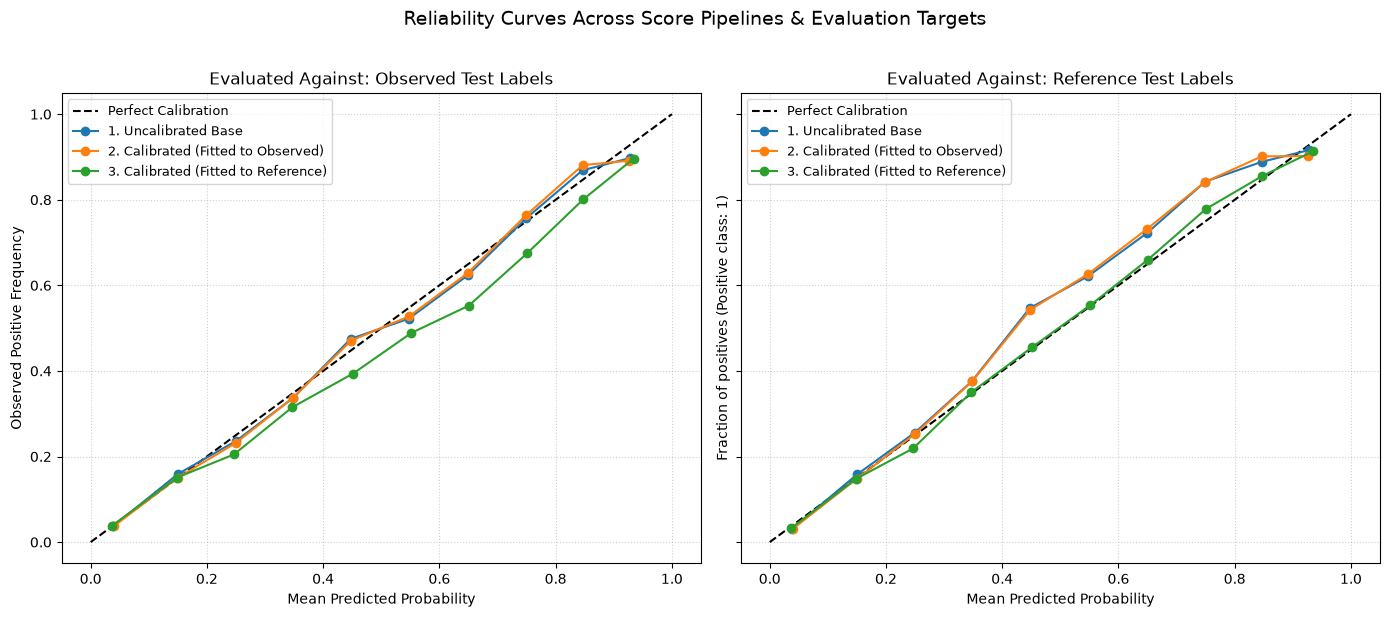

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax_idx, (target_name, y_true) in enumerate(test_targets.items()):
    ax = axes[ax_idx]

    # Reference baseline diagonal
    ax.plot([0, 1], [0, 1], "k--", label="Perfect Calibration")

    for pipe_name, model in pipelines.items():
        scores = np.clip(model.predict_proba(X_test)[:, 1], 0.0, 1.0)

        # Plot calibration curve
        disp = CalibrationDisplay.from_predictions(
            y_true=y_true,
            y_prob=scores,
            n_bins=10,
            name=pipe_name,
            ax=ax,
            marker="o",
            ref_line=False
        )

    ax.set_title(f"Evaluated Against: {target_name}", fontsize=12)
    ax.set_xlabel("Mean Predicted Probability", fontsize=10)
    if ax_idx == 0:
        ax.set_ylabel("Observed Positive Frequency", fontsize=10)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=9)

plt.suptitle(
    "Reliability Curves Across Score Pipelines & Evaluation Targets",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

## 5. Final locked test evaluation

Select the final candidates before examining reference test results. Then produce evaluate a comparison with:

- performance against $Y^{obs}$ and $Y^{ref}$;
- sex-specific and intersectional counts;
- selection-rate gap;
- TPR and FPR gaps;
- PPV and NPV gaps;
- AUROC, log loss, and calibration error;
- bootstrap intervals for key gaps;
- number of training examples removed/reweighted;
- features required at deployment.
- etc

## Questions to think about!

1. Which Week 2 conclusions were robust to the reference label audit?
2. Which apparent performance or fairness results were artifacts of $Y^{obs}$?
3. How did the suspected issue X affect in-distribution validation and shifted test performance?
4. How methods/framework helped you find issues in the data? How do you know?
5. Which mitigation improved reference performance, and what did it cost?
6. Did a parity intervention improve the chosen harm-related metric against the correct label?
7. How did observed-label and reference-label calibration differ?
8. Why can equalized odds and calibration conflict when group base rates differ?
9. What evidence would be required before changing real labels or deploying group-specific thresholds?
10. What remains unvalidated?

# 📌 Final Submission for Project 1: A0 Poster

You are instructed to submit an A0 poster summarizing  findings across the three weeks.

## 📋 Recommended Poster Structure

### Introduction & Setup (very breifly)

* The prediction task, dataset, and outcome. 
* The critical distinction between $Y^{obs}$ (the potential corrupted label) and $Y^{ref}$ (the clean ground-truth label).

### Week 1: Baseline Fairness Audit

* Overall and group-specific predictive performance.
* Fairness metrics considered and the real-world trade-offs observed.

### Week 2: Blind Audit (Observed Labels)

* You must explain initial hypotheses (e.g., Data collection flaws? Group-dependent errors? Spurious correlations?).
* What audit methods they used, their strongest evidence, and whether they trust derived scores as ground truth.

### Week 3: Reference Label Evaluation and Mitigation

* Reveal the hidden data problem using $Y^{ref}$ and quantify the disagreement between the observed and reference labels.
* Discuss whether your Week 2 hypotheses were correct.
* Mitigation: Compare a justified set of interventions. Report the effect on performance, fairness, calibration, and any adverse effects.
* Final Selection: Present the final model selection and its evaluation on the reference test set.
* Discussion and Conclusion

### Important

* Use visual evidence (tables/figures) throughout the poster. Focus on interpretation over code.

* Report relevant negative or inconclusive findings. What remains unvalidated?